# Week 7  A "functional" notebook

### Xingxiang Huang
### Group Name: LA Transporter

## **Step 1 Population Density Map**

/opt/conda/lib/python3.11/site-packages/contextily/tile.py:645: UserWarning: The inferred zoom level of 26 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


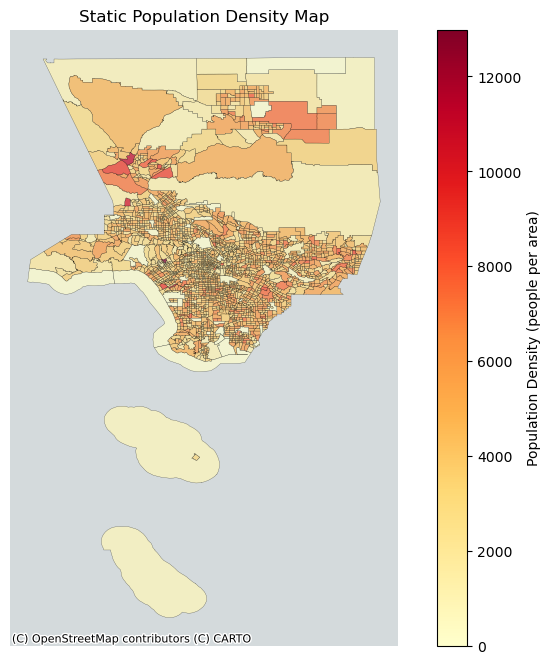

In [17]:
import json
import folium
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Load population data
population_data = pd.read_csv("Cleaned_Census_Population.csv")
population_data["FIPS"] = population_data["FIPS"].astype(str).str.zfill(11)

# Load GeoJSON data
with open("tracts_grouped.geojson", "r", encoding="utf-8") as file:
    geojson_raw = json.load(file)

# Convert GeoJSON into a structured format
geojson_for_folium = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"FIPS": feature["properties"].get("FIPS")},
            "geometry": feature["geometry"]
        }
        for feature in geojson_raw.get("features", [])
    ]
}

# Create a mapping of FIPS to population data
fips_population_map = dict(zip(population_data["FIPS"], population_data["Total population"]))

# Assign population values to GeoJSON properties
for feature in geojson_for_folium["features"]:
    fips_code = feature["properties"]["FIPS"]
    feature["properties"]["Population"] = fips_population_map.get(fips_code, 0)

# Define population density thresholds for better visualization
threshold_scale = [
    population_data["Total population"].min(),
    population_data["Total population"].quantile(0.25),
    population_data["Total population"].median(),
    population_data["Total population"].quantile(0.75),
    population_data["Total population"].max(),
]

# Function to generate an interactive population density map
def generate_population_map(output_file="Population_Density_Map.html"):
    """Creates an interactive population density map using folium."""
    m = folium.Map(location=[34.05, -118.25], zoom_start=10, tiles="CartoDB positron")

    folium.Choropleth(
        geo_data=geojson_for_folium,
        data=population_data,
        columns=["FIPS", "Total population"],
        key_on="feature.properties.FIPS",
        fill_color="YlOrRd",
        fill_opacity=0.7,
        line_opacity=0.2,
        threshold_scale=threshold_scale,
        legend_name="Population Density (people per area)",
    ).add_to(m)

    m.save(output_file)


# Function to generate a static population density map
def generate_static_population_map(output_file="Static_Population_Density.png"):
    """Creates a static population density map using geopandas and contextily."""
    gdf = gpd.GeoDataFrame.from_features(geojson_for_folium["features"])

    # Ensure 'Population' exists
    if "Population" not in gdf.columns:
        gdf["Population"] = 0
    
    fig, ax = plt.subplots(figsize=(10, 8))
    gdf.plot(column="Population", cmap="YlOrRd", linewidth=0.2, edgecolor="black",
             legend=True, legend_kwds={'label': "Population Density (people per area)"},
             alpha=0.7, ax=ax)

    # Add basemap similar to folium's "CartoDB positron"
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=gdf.crs)

    ax.set_title("Static Population Density Map")
    plt.axis("off")
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()


# Generate both interactive and static maps
generate_population_map()
generate_static_population_map()


The population density map visualizes the distribution of residents across Los Angeles County, highlighting high-density areas like Downtown LA, Koreatown, and Westlake, and low-density suburban regions such as Malibu and Calabasas. The color gradient (yellow to red) clearly distinguishes these variations.

Key Insights:

1. Higher-density areas have more pedestrians and cyclists, potentially increasing road safety risks.
2. Lower-density areas have more space but may lack dedicated bike infrastructure.
3. Understanding population density helps identify where bicycle safety improvements are most needed.

This visualization serves as the foundation for further analysis, examining how bicycle crashes correlate with population density to assess safety and equity concerns.

## **Step 2 Population Density with Crashes Map**

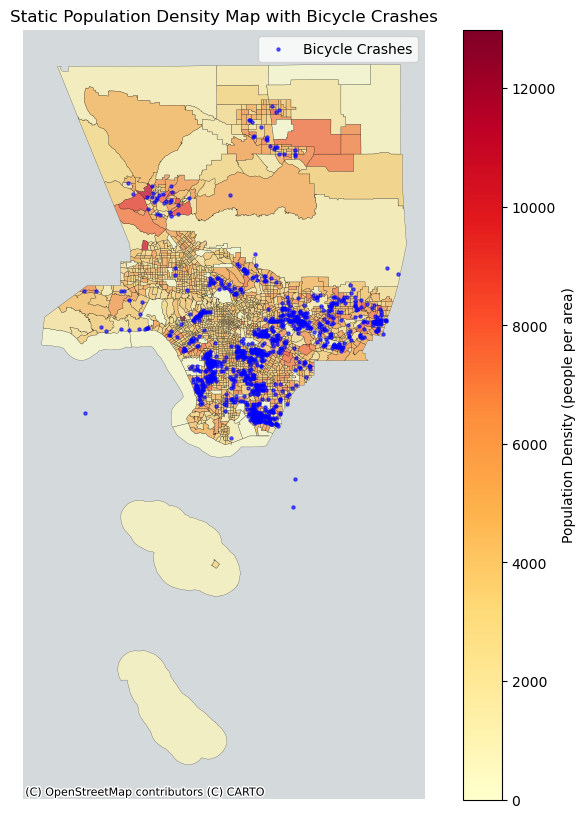

In [18]:
import json
import folium
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Load population data
population_data = pd.read_csv("Cleaned_Census_Population.csv")
population_data["FIPS"] = population_data["FIPS"].astype(str).str.zfill(11)

# Load GeoJSON
with open("tracts_grouped.geojson", "r", encoding="utf-8") as file:
    geojson_data = json.load(file)

# Convert GeoJSON into a GeoDataFrame
gdf = gpd.GeoDataFrame.from_features(geojson_data["features"])

# Fix 'FIPS' extraction issue
if "properties" in gdf.columns:
    gdf = pd.json_normalize(geojson_data["features"])  # Extract properties correctly

# Ensure 'FIPS' column is properly formatted
gdf["FIPS"] = gdf["FIPS"].astype(str).str.zfill(11)

# Map population data to FIPS
gdf["Population"] = gdf["FIPS"].map(dict(zip(population_data["FIPS"], population_data["Total population"]))).fillna(0)

# Load and clean bicycle crash data
crash_data = pd.read_csv("23_Bicycle_Crashes.csv").dropna(subset=["LATITUDE", "LONGITUDE"])
crash_data["LATITUDE"] = pd.to_numeric(crash_data["LATITUDE"], errors="coerce")
crash_data["LONGITUDE"] = pd.to_numeric(crash_data["LONGITUDE"], errors="coerce")
crash_data = crash_data.dropna(subset=["LATITUDE", "LONGITUDE"])

# Filter out extreme outlier points (keep only those within LA County)
crash_data = crash_data[
    (crash_data["LATITUDE"] > 33.5) & (crash_data["LATITUDE"] < 34.8) & 
    (crash_data["LONGITUDE"] > -119) & (crash_data["LONGITUDE"] < -117.5)
]

# Convert crash data into a GeoDataFrame
crash_gdf = gpd.GeoDataFrame(crash_data, geometry=gpd.points_from_xy(crash_data["LONGITUDE"], crash_data["LATITUDE"]), crs="EPSG:4326")

# Define color thresholds for better visualization
threshold_scale = [
    population_data["Total population"].min(),
    population_data["Total population"].quantile(0.25),
    population_data["Total population"].median(),
    population_data["Total population"].quantile(0.75),
    population_data["Total population"].max(),
]

# Function to generate an interactive folium map
def generate_interactive_map(output_file="Population_Density_with_Crashes.html"):
    """Creates an interactive map with population density and bicycle crash markers."""
    m = folium.Map(location=[34.05, -118.25], zoom_start=10, tiles="CartoDB positron")

    folium.Choropleth(
        geo_data=geojson_data,
        data=population_data,
        columns=["FIPS", "Total population"],
        key_on="feature.properties.FIPS",
        fill_color="YlOrRd",
        fill_opacity=0.7,
        line_opacity=0.2,
        threshold_scale=threshold_scale,
        legend_name="Population Density (people per area)",
    ).add_to(m)

    # Add crash markers
    for _, row in crash_data.iterrows():
        folium.CircleMarker(
            location=[row["LATITUDE"], row["LONGITUDE"]],
            radius=3,
            color="blue",
            fill=True,
            fill_color="blue",
            fill_opacity=0.6,
            popup=f"Date: {row['COLLISION_DATE']}, City: {row['CITY']}",
        ).add_to(m)

    m.save(output_file)
    return m

# Function to generate a static population density map with bicycle crashes
def generate_static_map(output_file="Static_Population_Density_with_Crashes.png"):
    """Creates a static population density map with bicycle crashes."""
    fig, ax = plt.subplots(figsize=(10, 10))  # Increased figure size for better visibility

    # Plot population density
    gdf.plot(column="Population", cmap="YlOrRd", linewidth=0.2, edgecolor="black",
             legend=True, legend_kwds={'label': "Population Density (people per area)"},
             alpha=0.7, ax=ax)
    
    # Plot bicycle crash points
    crash_gdf.plot(ax=ax, markersize=5, color="blue", alpha=0.6, label="Bicycle Crashes")

    # Add basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=gdf.crs, zoom=11)  # Adjusted zoom for better focus

    ax.set_title("Static Population Density Map with Bicycle Crashes")
    ax.legend()
    plt.axis("off")
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

# Generate both interactive and static maps
generate_interactive_map()
generate_static_map()


This analysis focuses on the spatial distribution of bicycle crashes in Los Angeles and their correlation with population density. The interactive map visualizes population density across census tracts using a choropleth, while individual crash locations are marked as blue points.

Through this visualization, we can observe that crash occurrences are concentrated in high-density areas, particularly in central and downtown LA. This supports the hypothesis that higher population density corresponds to increased bicycle crash frequency, potentially due to higher cycling activity and traffic interaction. 

## **Step 3 Crash Rate Map**

/tmp/ipykernel_3492/3924837858.py:18: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:4269

  crash_with_fips = gpd.sjoin(crash_gdf, tracts_gdf, how="left", predicate="within")
/tmp/ipykernel_3492/3924837858.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  crash_rates["Total population"].replace(0, np.nan, inplace=True)


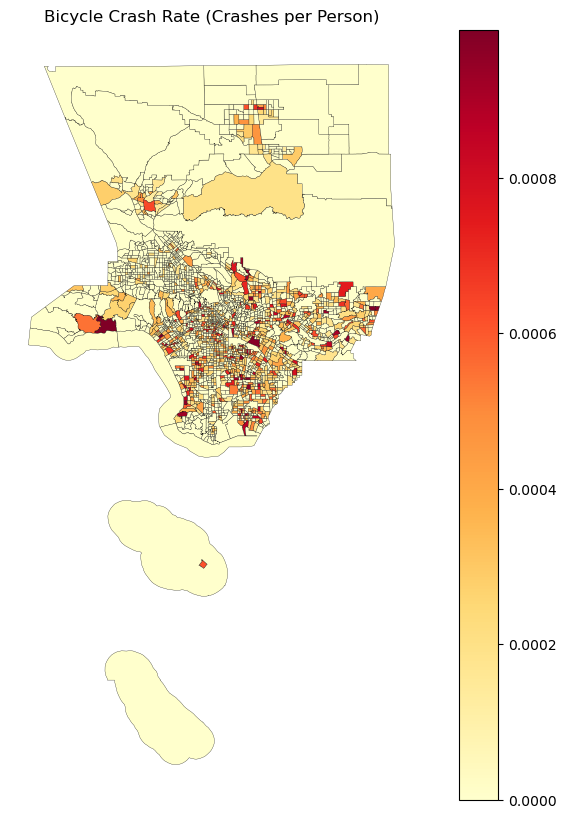

In [20]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import folium
import matplotlib.pyplot as plt

# Function to process crash data
def load_crash_data(file_path):
    crash_data = pd.read_csv(file_path)
    crash_data = crash_data.dropna(subset=["POINT_Y", "POINT_X"])
    return gpd.GeoDataFrame(
        crash_data, geometry=[Point(xy) for xy in zip(crash_data["POINT_X"], crash_data["POINT_Y"])], crs="EPSG:4326"
    )

# Function to compute crash rates
def compute_crash_rates(crash_gdf, tracts_gdf, population_data):
    crash_with_fips = gpd.sjoin(crash_gdf, tracts_gdf, how="left", predicate="within")
    crash_counts = crash_with_fips.groupby("FIPS").size().reset_index(name="crash_count")
    population_data["FIPS"] = population_data["FIPS"].astype(str).str.zfill(11)
    crash_counts["FIPS"] = crash_counts["FIPS"].astype(str).str.zfill(11)
    crash_rates = population_data.merge(crash_counts, on="FIPS", how="left").fillna(0)
    crash_rates["Total population"].replace(0, np.nan, inplace=True)
    crash_rates["crash_rate"] = crash_rates["crash_count"] / crash_rates["Total population"]
    return crash_rates[crash_rates["crash_rate"] <= crash_rates["crash_rate"].quantile(0.97)]

# Function to generate an interactive crash rate map
def generate_folium_map(geojson_path, crash_rates, output_html):
    m = folium.Map(location=[34.05, -118.25], zoom_start=10, tiles="CartoDB positron")
    folium.Choropleth(
        geo_data=geojson_path, data=crash_rates,
        columns=["FIPS", "crash_rate"], key_on="feature.properties.FIPS",
        fill_color="YlOrRd", fill_opacity=0.7, line_opacity=0.2,
        threshold_scale=[0, crash_rates["crash_rate"].quantile(0.50), crash_rates["crash_rate"].quantile(0.75),
                         crash_rates["crash_rate"].quantile(0.90), crash_rates["crash_rate"].max() * 1.1],
        legend_name="Bicycle Crash Rate (Crashes per Person)",
    ).add_to(m)
    m.save(output_html)

# Function to generate a static crash rate map
def generate_static_map(geojson_path, crash_rates, output_png):
    fig, ax = plt.subplots(figsize=(12, 10))
    tracts_gdf = gpd.read_file(geojson_path)
    merged_gdf = tracts_gdf.merge(crash_rates, on="FIPS", how="left").fillna(0)
    merged_gdf.plot(column="crash_rate", cmap="YlOrRd", linewidth=0.2, edgecolor="black", legend=True, ax=ax)
    ax.set_title("Bicycle Crash Rate (Crashes per Person)")
    ax.axis("off")
    plt.savefig(output_png, dpi=300, bbox_inches='tight')
    plt.show()

# File paths
crash_data_path = "23_Bicycle_Crashes.csv"
geojson_path = "tracts_grouped.geojson"
population_data_path = "Cleaned_Census_Population.csv"

# Load data
crash_gdf = load_crash_data(crash_data_path)
tracts_gdf = gpd.read_file(geojson_path)
population_data = pd.read_csv(population_data_path)

# Compute crash rates
crash_rates_filtered = compute_crash_rates(crash_gdf, tracts_gdf, population_data)

# Generate maps
generate_folium_map(geojson_path, crash_rates_filtered, "Crash_Rate_Map.html")
generate_static_map(geojson_path, crash_rates_filtered, "Crash_Rate_Map.png")


This analysis provides a spatial examination of bicycle crash rates across Los Angeles census tracts, integrating crash incident data with demographic population figures. The interactive Folium map enables an exploratory view where users can analyze geographic variations in crash rates. 

Detailed steps are bellow: crash locations are processed into a GeoDataFrame, spatially joined with census tracts, and then normalized by population data to compute crash rates per capita. Notably, the exclusion of the highest 3% quantile of crash rates ensures that extreme outliers do not distort the overall trends.

From the visual results, we observe that higher crash rates are predominantly in dense urban areas such as Downtown LA and South LA, consistent with regions that experience high bicycle usage and traffic interactions. Conversely, lower-density suburban areas exhibit fewer crashes, highlighting potential disparities in bicycle safety and infrastructure needs.